In [7]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
import numpy as np

spark = SparkSession.builder.master("local[10]").getOrCreate()
spark.sparkContext.setLogLevel("ERROR")

df = spark.read.parquet("/home/h487/data/parquet/run1008_srppac.parquet")#.select("id_x","timing_x","charge_x","id_y","timing_y","charge_y")
df.show(5)

+---------+--------------------+--------------------+--------------------+------+------------------+------------------+------------------+------------------+-----+-----+-----+--------------------+--------------------+--------------------+--------------------+------+-------------------+-----------------+------------------+------------------+-----+-----+-----+--------------------+-------+
|hbfNumber|                id_x|            timing_x|            charge_x|size_x|         timing0_x|         charge0_x|         charge1_x|         charge2_x|id0_x|id1_x|id2_x|              q0q1_x|                id_y|            timing_y|            charge_y|size_y|          timing0_y|        charge0_y|         charge1_y|         charge2_y|id0_y|id1_y|id2_y|              q0q1_y|runname|
+---------+--------------------+--------------------+--------------------+------+------------------+------------------+------------------+------------------+-----+-----+-----+--------------------+--------------------+---

Statistics:
[[0.00000e+00 0.00000e+00 0.00000e+00]
 [0.00000e+00 8.28262e+05 0.00000e+00]
 [0.00000e+00 3.90000e+01 0.00000e+00]]
Statistics:
[[0.00000e+00 0.00000e+00 0.00000e+00]
 [0.00000e+00 7.86982e+05 0.00000e+00]
 [0.00000e+00 1.80000e+01 0.00000e+00]]
Statistics:
[[     0.      0.      0.]
 [     0. 828301.      0.]
 [     0.      0.      0.]]
Statistics:
[[     0.      0.      0.]
 [     0. 787000.      0.]
 [     0.      0.      0.]]


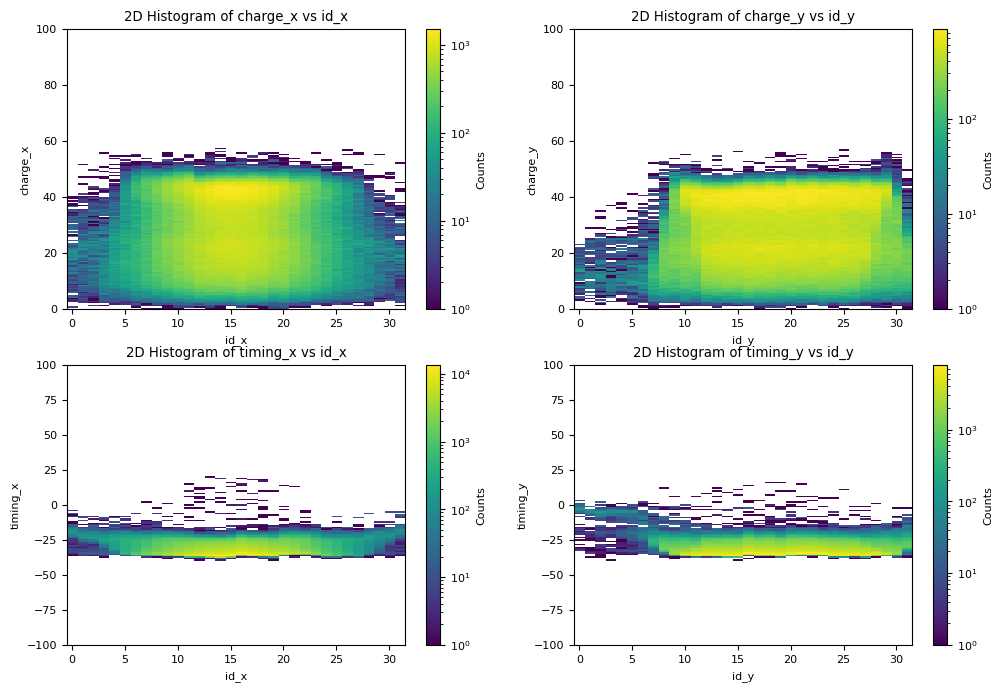

In [8]:
from hist.sparkHist2d import Hist2DArrays
from matplotlib import pyplot as plt
from matplotlib.colors import LogNorm

plt.figure(0, figsize=(12,8))
plt.rcParams["font.size"] = 8
plt.subplot2grid((2,2),(0,0))
h = Hist2DArrays(df, ["id_x","charge_x"], [33,200], [[-0.5, 31.5], [0, 100]], norm=LogNorm(), interpolation='none')
plt.subplot2grid((2,2),(0,1))
h = Hist2DArrays(df, ["id_y","charge_y"], [33,200], [[-0.5, 31.5], [0, 100]], norm=LogNorm(), interpolation='none')
plt.subplot2grid((2,2),(1,0))
h = Hist2DArrays(df, ["id_x","timing_x"], [33,200], [[-0.5, 31.5], [-100, 100]], norm=LogNorm(), interpolation='none')
plt.subplot2grid((2,2),(1,1))
h = Hist2DArrays(df, ["id_y","timing_y"], [33,200], [[-0.5, 31.5], [-100, 100]], norm=LogNorm(), interpolation='none')

plt.show()